In [1]:
import numpy as np
import xarray as xr
import rioxarray
from iotools import read_AsciiGrid

# ── Paths ──────────────────────────────────────────────────────────────────────
INPUT_NC  = '/Users/jpnousu/Downloads/data10x10_1980_2025_with_derivatives_old_format_subset.nc'
OUTPUT_NC = r'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/SpaFHy_RUNS/forcing/hiket_forcing_example.nc'
INPUT_ASCII_LAT = r'/Users/jpnousu/Models/SpaFHy_Peat_HIKET/hiket_inputs/sites_forest_ensembles/parameters/latitude.dat'
INPUT_ASCII_LON = r'/Users/jpnousu/Models/SpaFHy_Peat_HIKET/hiket_inputs/sites_forest_ensembles/parameters/longitude.dat'
CO2       = 400.0
U_DEFAULT = 2.0

# ── 1. Open source ─────────────────────────────────────────────────────────────
print("Opening source NetCDF...")
ds = xr.open_dataset(INPUT_NC)
print(ds)

# ── 2. Select and convert variables ───────────────────────────────────────────
print("Selecting and converting variables...")
out = xr.Dataset({
    'air_temperature':        ds['Tavg'],
    'precipitation':          ds['Prec'].fillna(0.0),
    'global_radiation':       ds['Rg'],
    'par':                    ds['PAR'],
    'vapor_pressure_deficit': ds['vpd'].clip(min=0.0),
    'degree_days':            ds['Tempsum_a'],
    'doy': xr.DataArray(
           np.tile(ds['time'].dt.dayofyear.values, (ds.dims['lat'], ds.dims['lon'], 1)),
           dims=['lat', 'lon', 'time'],
       ),
    'CO2':                    xr.full_like(ds['Tavg'], CO2),
    'wind_speed':             xr.full_like(ds['Tavg'], U_DEFAULT),
})

# ── 3. Reproject KKJ → WGS84 with rioxarray ────────────────────────────────────
print("Reprojecting KKJ → WGS84 with rioxarray...")

# rioxarray expects (time, y, x) — transpose from (lat, lon, time)
out = out.transpose("time", "lat", "lon")

# Set spatial dims and assign source CRS
out = out.rio.set_spatial_dims(x_dim='lon', y_dim='lat')
out = out.rio.write_crs("EPSG:2393")

# Reproject to WGS84 — rioxarray handles all coordinate transformation
out = out.rio.reproject("EPSG:4326")

# ── 4. Add variable metadata ───────────────────────────────────────────────────
out['air_temperature'].attrs        = {'units': 'degC',     'long_name': 'Daily mean air temperature'}
out['precipitation'].attrs          = {'units': 'mm day-1', 'long_name': 'Daily precipitation'}
out['global_radiation'].attrs       = {'units': 'W m-2',    'long_name': 'Global radiation'}
out['par'].attrs                    = {'units': 'W m-2',    'long_name': 'Photosynthetically active radiation'}
out['vapor_pressure_deficit'].attrs = {'units': 'kPa',      'long_name': 'Vapor pressure deficit'}
out['wind_speed'].attrs             = {'units': 'm s-1',    'long_name': 'Wind speed (constant default)'}
out['CO2'].attrs                    = {'units': 'ppm',      'long_name': 'CO2 concentration (constant)'}
out['doy'].attrs                    = {'units': '-',        'long_name': 'Day of year'}
out['degree_days'].attrs            = {'units': 'degC',     'long_name': 'Annual temperature sum'}

out.attrs = {
    'description':     'SpaFHy driver-ready forcing, 10x10km grid, Finland 1980-2025',
    'source':          INPUT_NC,
    'CRS':             'EPSG:4326',
    'CO2_ppm':         CO2,
    'wind_speed_note': 'Constant default, override per simulation if needed',
}

# -- 5. Make a new out dataset so that it the lat and lon shape from INPUT_ASCII_LAT and INPUT_ASCII_LON
lats, _, _, _, _ = read_AsciiGrid(INPUT_ASCII_LAT)
lons, _, _, _, _ = read_AsciiGrid(INPUT_ASCII_LON)

# Flatten to 1D regardless of input shape, remember original shape
original_shape = lats.shape
lats_flat = lats.ravel()
lons_flat = lons.ravel()
n_cells = len(lats_flat)

# Find nearest x and y indices in out for each site coordinate
x_coords = out['x'].values
y_coords = out['y'].values

x_idx = np.abs(x_coords[None, :] - lons_flat[:, None]).argmin(axis=1)
y_idx = np.abs(y_coords[None, :] - lats_flat[:, None]).argmin(axis=1)

# ── 6. Build new dataset with site shape ──────────────────────────────────────
n_dates = out.dims['time']
site_ds = xr.Dataset(coords={
    'time': out['time'],
    'lat':  (['cell'], lats_flat),
    'lon':  (['cell'], lons_flat),
})

for var in out.data_vars:
    # Extract nearest grid cell for each site: shape (n_dates, n_cells)
    data = out[var].values[:, y_idx, x_idx]  # (time, n_cells)
    site_ds[var] = xr.DataArray(data, dims=['time', 'cell'], attrs=out[var].attrs)

# Reshape cell dim back to original shape if 2D
if lats.ndim == 2:
    site_ds = site_ds.assign_coords(
        lat=(['cell'], lats_flat),
        lon=(['cell'], lons_flat),
    )
    # reshape each variable to (time, i, j)
    i, j = original_shape
    reshaped = xr.Dataset(coords={
        'time': out['time'],
        'i': np.arange(i),
        'j': np.arange(j),
    })
    for var in site_ds.data_vars:
        reshaped[var] = xr.DataArray(
            site_ds[var].values.reshape(n_dates, i, j),
            dims=['time', 'i', 'j'],
            attrs=site_ds[var].attrs
        )
    site_ds = reshaped

site_ds.attrs = out.attrs
site_ds = site_ds.rename({'time': 'date'})
site_ds.to_netcdf(OUTPUT_NC)

Opening source NetCDF...
<xarray.Dataset> Size: 319MB
Dimensions:    (lat: 116, lon: 67, time: 366)
Coordinates:
  * lon        (lon) int64 536B 3075000 3085000 3095000 ... 3725000 3735000
  * lat        (lat) int64 928B 6635000 6645000 6655000 ... 7775000 7785000
  * time       (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables: (12/14)
    Tavg       (lat, lon, time) float64 23MB ...
    Tmin       (lat, lon, time) float64 23MB ...
    Tmax       (lat, lon, time) float64 23MB ...
    GlobR      (lat, lon, time) float64 23MB ...
    PH2O       (lat, lon, time) float64 23MB ...
    Prec       (lat, lon, time) float64 23MB ...
    ...         ...
    PAR        (lat, lon, time) float64 23MB ...
    esa        (lat, lon, time) float64 23MB ...
    vpd        (lat, lon, time) float64 23MB ...
    RH         (lat, lon, time) float64 23MB ...
    Precsum_a  (lat, lon, time) float64 23MB ...
    Tempsum_a  (lat, lon, time) float64 23MB ...
Attributes:
    descripti

/var/folders/ql/krv8pzs127n_r0j8j744gxpr0000gn/T/ipykernel_20368/753274492.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  np.tile(ds['time'].dt.dayofyear.values, (ds.dims['lat'], ds.dims['lon'], 1)),


Reprojecting KKJ → WGS84 with rioxarray...


/var/folders/ql/krv8pzs127n_r0j8j744gxpr0000gn/T/ipykernel_20368/753274492.py:86: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_dates = out.dims['time']


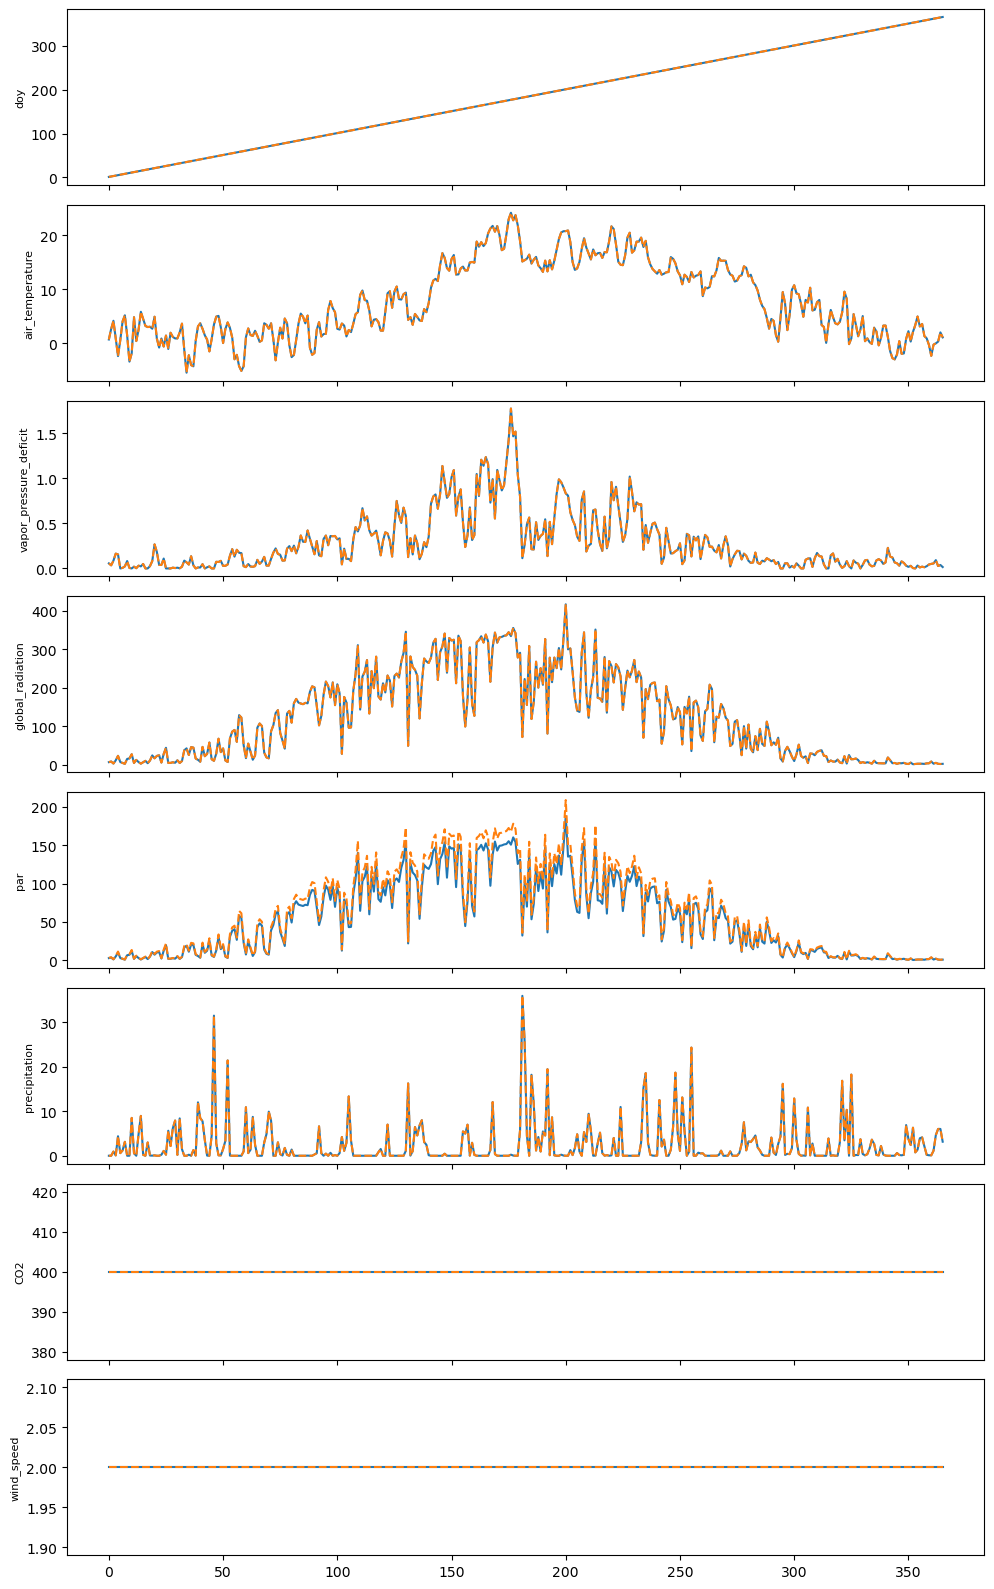

In [3]:
import matplotlib.pyplot as plt

variables = list(dummy.data_vars)
n = len(variables)
fig, axes = plt.subplots(n, 1, figsize=(10, n * 2), sharex=True)

for ax, var in zip(axes, variables):
    ax.plot(dummy[var][:, 0, 0])
    ax.plot(site_ds[var][:, 0, 0], linestyle='--')
    ax.set_ylabel(var, fontsize=8)

plt.tight_layout()
plt.show()